# Organizational-Capital -- does accumulated know-how earn a premium?
### Eisfeldt-Papanikolaou (2013): SG&A as investment, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Premium-sign: Busted](https://img.shields.io/badge/Premium--sign-Busted-8b949e?style=flat-square)

In 2013, Andrea Eisfeldt and Dimitris Papanikolaou published a clever idea: a firm's **organizational capital** -- the know-how, processes, and culture built up over years of spending on Selling, General & Administrative (SG&A) -- is a real, productive asset, even though accountants expense it. They argued high-org-capital firms should earn **higher** returns, because that capital is partly embodied in *talent that can walk out the door*: shareholders bear that mobility risk and demand a premium.

We capitalize SG&A by perpetual inventory, scale by assets, and sort a large-cap **survivor** basket -- naming the survivorship bias and applying one execution lag.

> **This is the plain-language layer.** Want the perpetual-inventory build, the HAC *t*, the placebo, and the 12-seed control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from organizational_capital import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "oc_fundamentals.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "oc_prices.parquet")))

HAVE_REAL = _have_cache()
print("EDGAR + yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    fund = data.fetch_fundamentals()
    prices = data.fetch_prices()
    oc = st.org_capital_stock(fund)
    monthly = prices.resample("ME").last().pct_change().dropna(how="all")
    ls = st.long_short(oc, monthly)
    s_ls = st.summary(ls["ls"]); s_hi = st.summary(ls["high"]); s_lo = st.summary(ls["low"])
    print(f"N months: {s_ls['n']} | LS: {s_ls['mean']*100:+.2f}%/yr | HAC t: {s_ls['tstat']:+.3f}")


EDGAR + yfinance cache present: True


N months: 203 | LS: -1.68%/yr | HAC t: -0.923


## The answer first

| Question | Answer |
|---|---|
| Do high-OC firms out-earn low-OC firms? | **No, on this tape.** The high-minus-low long-short earns **-1.68%/yr**, HAC *t* = **-0.92** -- below the bar *and the wrong sign*. |
| Is the sign what E-P predicted? | **No.** They predict high-OC **>** low-OC; here the high-OC half (15.0%/yr) **trailed** the low-OC half (16.6%/yr). |
| Could you trade it? | **No.** The gross spread is already negative; costs only deepen it to **-2.28%/yr**. |
| Is the engine broken? | **No.** The synthetic control recovers a planted premium with the right sign -- so the flip is **the tape**, not the method. |

> The org-capital premium is a genuine, well-cited *risk story*. On a 39-name large-cap survivor basket it simply does not show up -- if anything it points the wrong way.

## 1 -- The claim

> *"Organization capital is a production factor embodied in the firm's key talent. Since this talent is mobile and has outside options, shareholders of high-org-capital firms bear more risk and earn higher average returns."*

-- Eisfeldt & Papanikolaou (2013), *Journal of Finance*

The accounting trick: treat **SG&A as investment**, not pure expense. Accumulate it into a stock that depreciates ~15%/yr (a perpetual inventory, exactly as you'd build a physical-capital stock from capex), then scale by book assets to compare across firm sizes. Sort. The high pile is predicted to pay.

## 2 -- So what?

If real, org-capital is an intangible risk factor that standard book-value accounting misses entirely -- and a whole literature (Peters-Taylor 2017; Eisfeldt-Falato-Xiaolan 2023) builds on capitalizing SG&A and R&D. The questions for us:

1. **Does the premium survive on a realistic large-cap panel?**
2. **Does it even have the right sign?**
3. **What does survivorship do to the risk story?** (The high-risk tail E-P load on the long leg are exactly the firms that *delist* -- and they're missing here.)

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Capitalize SG&A by perpetual inventory** with a published recipe (delta=15%, steady-state seed) -- no free parameters tuned to the answer.
2. **One execution lag.** The annual rank uses fiscal-year fundamentals already public (prior year); positions enter the month after and are held 12 months. No look-ahead.
3. **Name the survivorship bias.** The basket is current large-caps still trading in 2026. Delisted firms -- the natural high-risk long-leg names -- are absent. Any positive result would be an **upper bound**.

## 4 -- The teardown

**First, does the engine work when the premium is planted?**

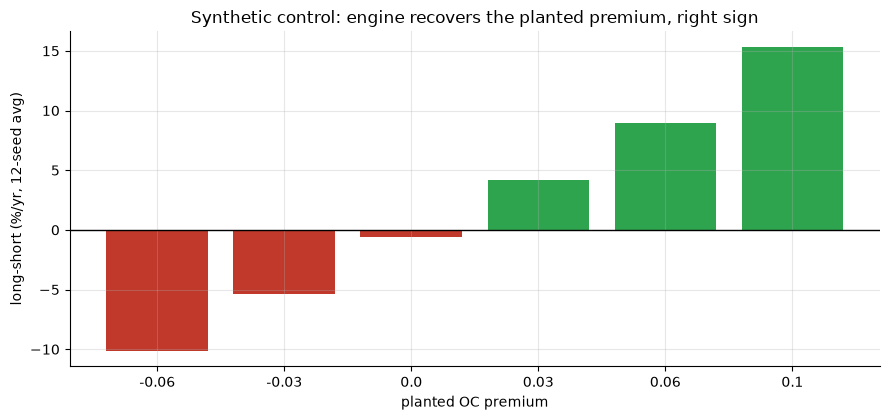

 premium  mean_ls_pct  mean_t
   -0.06       -10.17   -4.41
   -0.03        -5.38   -2.36
    0.00        -0.60   -0.27
    0.03         4.19    1.83
    0.06         8.98    3.92
    0.10        15.36    6.62


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.3 else (RED if m < -0.3 else GREY) for m in ctrl['mean_ls_pct']]
ax.bar(ctrl['premium'].astype(str), ctrl['mean_ls_pct'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted OC premium'); ax.set_ylabel('long-short (%/yr, 12-seed avg)')
ax.set_title('Synthetic control: engine recovers the planted premium, right sign')
plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))

The engine is faithful: the long-short is monotone in the planted premium and has the **correct sign**. So whatever the real tape says reflects **the market**, not a bug.

**Now the honest test on the real EDGAR + yfinance tape.**

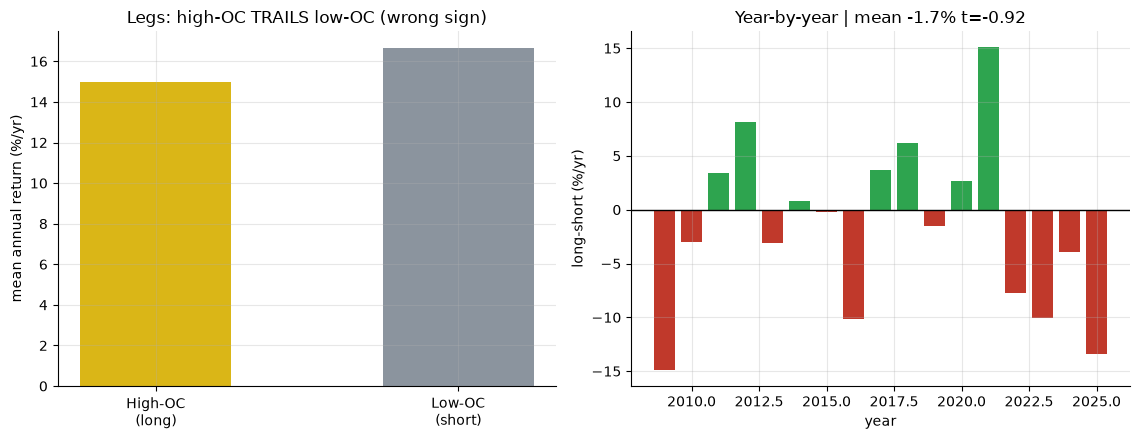

High-OC minus low-OC: -1.68%/yr | HAC t = -0.923


In [3]:
if HAVE_REAL:
    hi, lo = s_hi['mean']*100, s_lo['mean']*100
    lsm, lst = s_ls['mean']*100, s_ls['tstat']
    ls2 = ls.copy(); ls2['year'] = pd.DatetimeIndex(ls2.index).year
    annual = ls2.groupby('year')['ls'].apply(lambda x: float((1+x).prod()-1))*100
else:
    hi, lo = R['high_leg'], R['low_leg']
    lsm, lst = R['ls_gross'], R['ls_t']
    annual = pd.Series(R['annual'])
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].bar(['High-OC\n(long)', 'Low-OC\n(short)'], [hi, lo], color=[AMBER, GREY], width=.5)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Legs: high-OC TRAILS low-OC (wrong sign)')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index, annual.values, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('long-short (%/yr)')
axes[1].set_title(f'Year-by-year | mean {lsm:+.1f}% t={lst:+.2f}')
plt.tight_layout(); plt.show()
print(f'High-OC minus low-OC: {lsm:+.2f}%/yr | HAC t = {lst:+.3f}')

The high-minus-low spread earns **-1.68%/yr** at HAC *t* = **-0.92** -- below the bar and pointing the *wrong* way. High-OC large-caps did not out-earn low-OC ones over 2009-2025; they slightly **under**performed.

## 5 -- The verdict

- **Signal -- NONE.** -1.68%/yr, HAC *t* = -0.92, wrong sign; the label-shuffle placebo can't separate it from noise (*p* = 0.33).
- **Tradability -- MIRAGE.** The gross spread is negative; net of costs -2.28%/yr. There is nothing to trade.
- **Premium-sign -- BUSTED.** E-P predict a positive premium; on this survivor basket the sign flips. The synthetic control proves it's the tape, not the engine.

## 6 -- Could you actually trade it?

No. Even setting aside the wrong sign:

1. **The spread is negative gross**, and costs (transaction + short borrow) make it worse.
2. **Survivorship cuts the wrong way.** The risk story lives in firms that *might* lose their talent and fail -- but failed firms are exactly the ones deleted from a current-large-cap basket.
3. **SG&A is noisy across sectors.** A retailer and a software firm spend on utterly different SG&A; the cross-sectional sort mixes structural business-model differences with any true org-capital signal.

## 7 -- Going further

- **Broaden the universe.** The original paper used the full Compustat cross-section with delisted firms. A survivor-free, microcap-inclusive panel is the real test.
- **Industry-neutralize.** Sort *within* industry so SG&A intensity reflects org-capital, not business model.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)** and **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: two other risk-premium claims where the headline survives the literature but not a small survivor tape.

*Think org-capital pays once you fix survivorship and industry-neutralize? Fork this, add delisted names, and show t > 2 with the right sign net of costs. That is the bar.*